# Week 1: Data Cleaning and Exploratory Analysis
## Vortex Tech AI/ML Internship 2026
**Name:** Zainab Javed  
**Track:** AI & ML  
**Dataset:** Students Performance in Exams (Kaggle)  

### Objective
In this notebook, we will load the Students Performance dataset,
clean it, and perform exploratory data analysis using Python, Pandas,
Matplotlib and Seaborn to uncover insights about student scores.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Dataset load karna
df = pd.read_csv(r'E:\Vortex Tec Internship Tasks\aiml_Week1_Beginner\Dataset\StudentsPerformance.csv')

# Pehli 5 rows dekhna
print("Dataset ki pehli 5 rows:")
df.head()

Dataset ki pehli 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Dataset ki complete information
print("Dataset ka size:")
print(df.shape)

print("\nColumns aur Data Types:")
print(df.info())

Dataset ka size:
(1000, 8)

Columns aur Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [4]:
# Missing values check karna
print("Missing Values har column mein:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing Values har column mein:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows:
0


In [5]:
# DATA CLEANING
# Kyunki dataset already clean hai, hum confirm karenge

# Missing values handle karna
# Result: Koi missing values nahi mile, isliye koi action nahi liya
print("Missing values check: PASSED - Koi missing values nahi")

# Duplicates remove karna
df.drop_duplicates(inplace=True)
print("Duplicates check: PASSED - Koi duplicates nahi mile")

# Data types verify karna
# Scores already int64 hain jo bilkul sahi hai
# Text columns object type mein hain jo correct hai
print("Data types check: PASSED - Sab data types correct hain")

print(f"\nFinal dataset size: {df.shape[0]} rows, {df.shape[1]} columns")

Missing values check: PASSED - Koi missing values nahi
Duplicates check: PASSED - Koi duplicates nahi mile
Data types check: PASSED - Sab data types correct hain

Final dataset size: 1000 rows, 8 columns


In [6]:
# SUMMARY STATISTICS

# Statistic 1: Numerical columns ki complete summary
print("=== Statistic 1: Scores ki Summary ===")
print(df.describe())

# Statistic 2: Average scores by gender
print("\n=== Statistic 2: Gender ke hisaab se Average Scores ===")
print(df.groupby('gender')[['math score','reading score','writing score']].mean().round(2))

# Statistic 3: Test preparation course kitne students ne ki
print("\n=== Statistic 3: Test Preparation Course - Value Counts ===")
print(df['test preparation course'].value_counts())

=== Statistic 1: Scores ki Summary ===
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000

=== Statistic 2: Gender ke hisaab se Average Scores ===
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

=== Statistic 3: Test Preparation Course - Value Counts ===
test preparation course
none         642
completed    358
Name: count, dtype: int64


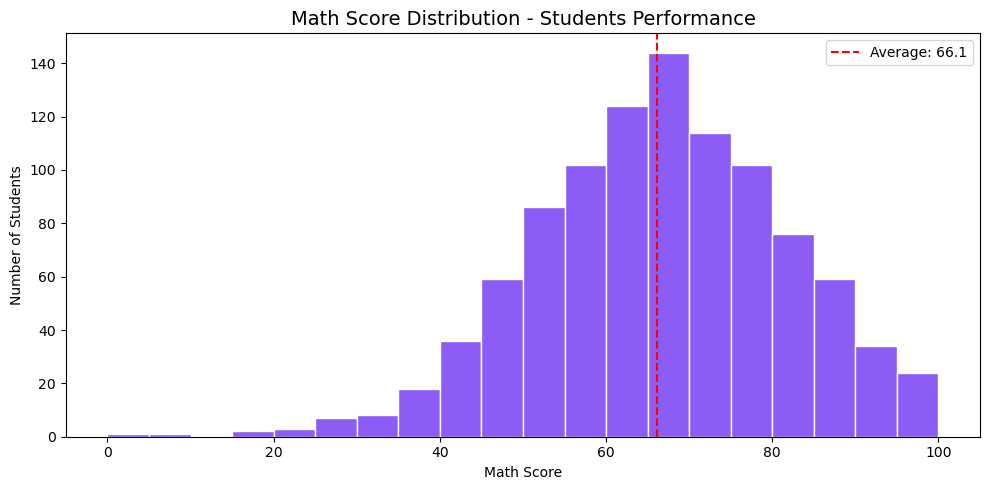

In [7]:
# VISUALIZATION 1: Math Score ka Histogram
plt.figure(figsize=(10, 5))
plt.hist(df['math score'], bins=20, color='#8b5cf6', edgecolor='white')
plt.title('Math Score Distribution - Students Performance', fontsize=14)
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.axvline(df['math score'].mean(), color='red', linestyle='--', label=f'Average: {df["math score"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

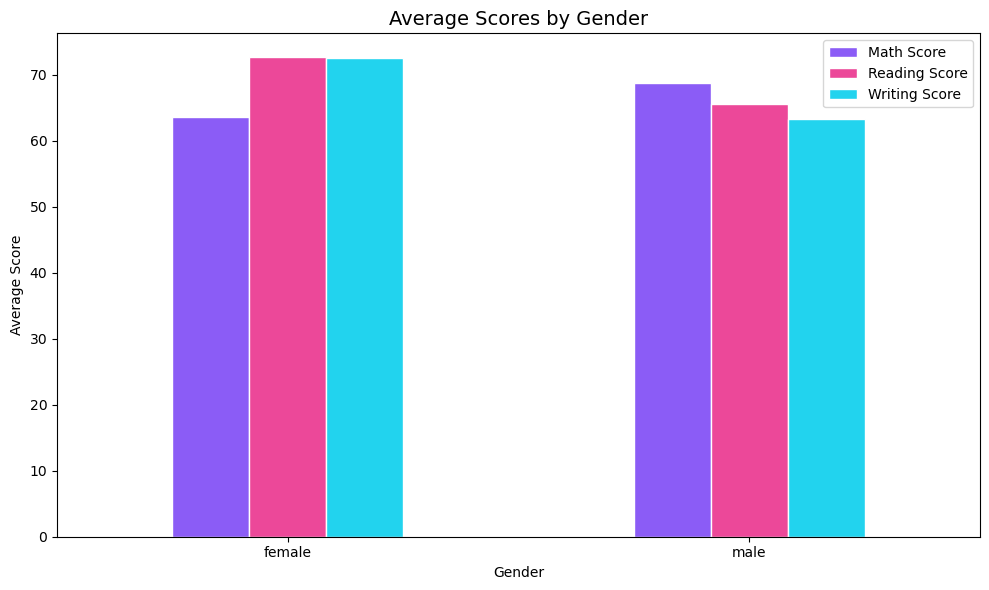

In [8]:
# VISUALIZATION 2: Gender ke hisaab se Average Scores - Bar Chart
gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

gender_scores.plot(kind='bar', figsize=(10, 6), 
                   color=['#8b5cf6', '#ec4899', '#22d3ee'],
                   edgecolor='white')

plt.title('Average Scores by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(['Math Score', 'Reading Score', 'Writing Score'])
plt.tight_layout()
plt.show()


C:\Users\pc\AppData\Local\Temp\ipykernel_16040\2162198723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test preparation course',


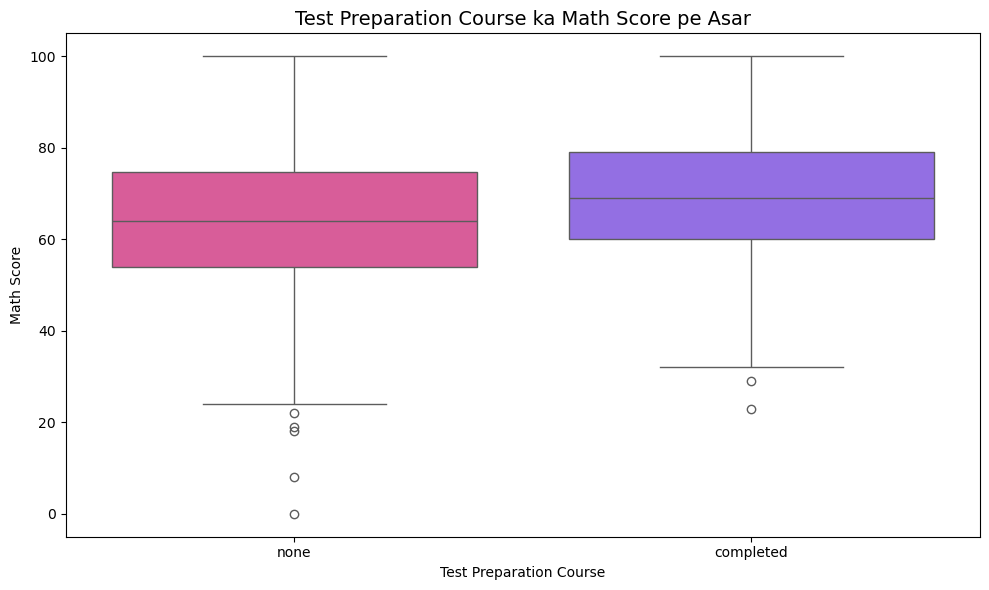

In [9]:
# VISUALIZATION 3 (Bonus): Test Prep Course ka Effect on Scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='test preparation course', 
            y='math score', 
            palette=['#ec4899', '#8b5cf6'])
plt.title('Test Preparation Course ka Math Score pe Asar', fontsize=14)
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.tight_layout()
plt.show()